INITIAL SANITY CHECK

In [ ]:
# Importing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
raw_data = pd.read_csv('/content/drive/MyDrive/kaggle 2025-2026 india.csv')
raw_data.head()

,city,state,Latitude,Longitude,timestamp,PM2.5,PM10,CO,NO2,SO2,O3
0,Agartala,Tripura,23.8315,91.2868,08/05/2022 0:00,14.8,21.5,197,21.8,2.7,32
1,Agartala,Tripura,23.8315,91.2868,08/05/2022 1:00,15.7,22.8,196,18.5,3.0,33
2,Agartala,Tripura,23.8315,91.2868,08/05/2022 2:00,16.3,23.5,196,15.1,3.3,34
3,Agartala,Tripura,23.8315,91.2868,08/05/2022 3:00,17.6,25.4,197,14.1,3.3,32
4,Agartala,Tripura,23.8315,91.2868,08/05/2022 4:00,18.2,26.2,199,13.9,3.2,30


In [ ]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [ ]:
raw_data = raw_data.sort_values(by='timestamp')
raw_data.head(10)

,city,state,Latitude,Longitude,timestamp,PM2.5,PM10,CO,NO2,SO2,O3
119736,Bhopal,Madhya Pradesh,23.2599,77.4126,01/01/2023 0:00,43.0,63.1,406,8.2,4.2,63
468216,Jaipur,Rajasthan,26.9124,75.7873,01/01/2023 0:00,55.9,82.9,1054,49.5,8.5,22
439176,Itanagar,Arunachal Pradesh,27.0844,93.6053,01/01/2023 0:00,15.4,22.2,218,3.3,0.6,52
410136,Imphal,Manipur,24.8170,93.9368,01/01/2023 0:00,38.2,54.7,470,8.7,7.6,64
642456,Patna,Bihar,25.5941,85.1376,01/01/2023 0:00,236.1,339.0,2480,88.7,40.2,15
177816,Chandigarh,Punjab,30.7333,76.7794,01/01/2023 0:00,63.1,90.3,1603,75.2,19.8,1
816696,Visakhapatnam,Andhra Pradesh,17.6868,83.2185,01/01/2023 0:00,80.8,120.1,2987,51.3,88.2,56
61656,Aizawl,Mizoram,23.7271,92.7176,01/01/2023 0:00,26.8,38.6,502,17.8,1.8,38
497256,Kohima,Nagaland,25.6751,94.1086,01/01/2023 0:00,26.5,38.0,574,15.1,1.2,38
584376,Mumbai,Maharashtra,19.0760,72.8777,01/01/2023 0:00,50.4,76.4,723,51.2,102.1,37


In [ ]:
raw_data.duplicated().sum()

np.int64(0)

In [ ]:
raw_data.isna().sum()

,0
city,0
state,0
Latitude,0
Longitude,0
timestamp,0
PM2.5,0
PM10,0
CO,0
NO2,0
SO2,0


In [ ]:
raw_data['timestamp'] = pd.to_datetime(raw_data['timestamp'], errors='coerce')
raw_data.dtypes

,0
city,object
state,object
Latitude,float64
Longitude,float64
timestamp,datetime64[ns]
PM2.5,float64
PM10,float64
CO,int64
NO2,float64
SO2,float64


In [ ]:
# Desired column order
desired_order = [
    'timestamp',
    'state', 'city', 'Latitude','Longitude',
    'PM2.5',
    'PM10',
    'NO2',
    'SO2',
   'O3',
   'CO'
]

# keep only columns that actually exist in the dataframe
existing_cols = [col for col in desired_order if col in raw_data.columns]

# final reordered dataframe
raw_data = raw_data[existing_cols]

raw_data.head()

,timestamp,state,city,Latitude,Longitude,PM2.5,PM10,NO2,SO2,O3,CO
119736,2023-01-01,Madhya Pradesh,Bhopal,23.2599,77.4126,43.0,63.1,8.2,4.2,63,406
468216,2023-01-01,Rajasthan,Jaipur,26.9124,75.7873,55.9,82.9,49.5,8.5,22,1054
439176,2023-01-01,Arunachal Pradesh,Itanagar,27.0844,93.6053,15.4,22.2,3.3,0.6,52,218
410136,2023-01-01,Manipur,Imphal,24.8170,93.9368,38.2,54.7,8.7,7.6,64,470
642456,2023-01-01,Bihar,Patna,25.5941,85.1376,236.1,339.0,88.7,40.2,15,2480


In [ ]:
kaggle_rename_map = {
    'PM2.5': 'PM2.5 (µg/m³)',
    'PM10': 'PM10 (µg/m³)',
    'NO2': 'NO2 (µg/m³)',
    'SO2': 'SO2 (µg/m³)',
    'O3': 'O3 (µg/m³)',
    'CO': 'CO (µg/m³)',
}

# Apply the renaming to your dataframe
raw_data = raw_data.rename(columns=kaggle_rename_map)

raw_data.columns.name = None

# Check the output
raw_data.head()

,timestamp,state,city,Latitude,Longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³)
119736,2023-01-01,Madhya Pradesh,Bhopal,23.2599,77.4126,43.0,63.1,8.2,4.2,63,406
468216,2023-01-01,Rajasthan,Jaipur,26.9124,75.7873,55.9,82.9,49.5,8.5,22,1054
439176,2023-01-01,Arunachal Pradesh,Itanagar,27.0844,93.6053,15.4,22.2,3.3,0.6,52,218
410136,2023-01-01,Manipur,Imphal,24.8170,93.9368,38.2,54.7,8.7,7.6,64,470
642456,2023-01-01,Bihar,Patna,25.5941,85.1376,236.1,339.0,88.7,40.2,15,2480


HANDLING OUTLIERS

In [ ]:
raw_data.describe()

,timestamp,Latitude,Longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³)
count,842160,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000
mean,2024-03-31 23:30:00.000000256,23.129041,82.769207,34.739642,56.257083,16.132833,13.599054,80.479350,450.891150
min,2022-08-05 00:00:00,8.524100,72.571400,0.100000,0.100000,-0.200000,-0.200000,-11.000000,56.000000
25%,2023-06-03 11:45:00,20.296100,77.173400,14.700000,21.500000,3.700000,2.800000,47.000000,235.000000
50%,2024-03-31 23:30:00,23.831500,80.946200,25.900000,39.000000,9.000000,6.900000,73.000000,333.000000
75%,2025-01-28 11:15:00,26.912400,88.606500,44.200000,66.400000,19.900000,15.800000,108.000000,508.000000
max,2025-11-26 23:00:00,31.104800,94.108600,581.100000,3263.400000,336.000000,424.600000,930.000000,14504.000000
std,NaN,5.543478,6.937205,30.843496,83.837033,20.813405,20.617020,46.196459,434.552149


In [ ]:
import numpy as np

# List of columns to check
pollutants = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)']

# Replace negative values with NaN (so they can be filled properly by your Interpolation step)
print("Checking for negative values...")
for col in pollutants:
    neg_count = (raw_data[col] < 0).sum()
    if neg_count > 0:
        print(f"Replacing {neg_count} negative values in {col} with NaN")
        raw_data.loc[raw_data[col] < 0, col] = np.nan
    else:
        print(f"No negative values found in {col}")

Checking for negative values...
No negative values found in PM2.5 (µg/m³)
No negative values found in PM10 (µg/m³)
Replacing 2 negative values in NO2 (µg/m³) with NaN
Replacing 4 negative values in SO2 (µg/m³) with NaN
Replacing 82 negative values in O3 (µg/m³) with NaN
No negative values found in CO (µg/m³)


In [ ]:
# List of pollutant columns to check
pollutants = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)']

print(f"Rows before removing negative values: {len(raw_data)}")

# Remove any row where a pollutant is less than 0
for col in pollutants:
    raw_data = raw_data[raw_data[col] >= 0]

print(f"Rows after removing negative values: {len(raw_data)}")

Rows before removing negative values: 842160
Rows after removing negative values: 842072


AQI CALCULATION

In [ ]:
import pandas as pd
import numpy as np
breakpoints = {
    'PM2.5 (µg/m³)': [
        (0, 30, 0, 50),
        (31, 60, 51, 100),
        (61, 90, 101, 200),
        (91, 120, 201, 300),
        (121, 250, 301, 400),
        (250.1, 500, 401, 500)
    ],
    'PM10 (µg/m³)': [
        (0, 50, 0, 50),
        (51, 100, 51, 100),
        (101, 250, 101, 200),
        (251, 350, 201, 300),
        (351, 430, 301, 400),
        (431, 600, 401, 500)
    ],
    'NO2 (µg/m³)': [
        (0, 40, 0, 50),
        (41, 80, 51, 100),
        (81, 180, 101, 200),
        (181, 280, 201, 300),
        (281, 400, 301, 400),
        (401, 600, 401, 500)
    ],
    'SO2 (µg/m³)': [
        (0, 40, 0, 50),
        (41, 80, 51, 100),
        (81, 380, 101, 200),
        (381, 800, 201, 300),
        (801, 1600, 301, 400),
        (1601, 2500, 401, 500)
    ],
    'CO (µg/m³)': [
        (0, 1000, 0, 50),
        (1001, 2000, 51, 100),
        (2001, 10000, 101, 200),
        (10001, 17000, 201, 300),
        (17001, 34000, 301, 400),
        (34001, 50000, 401, 500)
    ],
    'O3 (µg/m³)': [
        (0, 50, 0, 50),
        (51, 100, 51, 100),
        (101, 168, 101, 200),
        (169, 208, 201, 300),
        (209, 748, 301, 400),
        (749, 1000, 401, 500)
    ]
}

# CALCULATE AQI SUB-INDICES
import numpy as np

def calculate_sub_index_fast(series, pollutant_name):
    """
    Super-fast Numpy implementation of AQI calc.
    5x-10x faster than Pandas .apply() or standard masking.
    """
    vals = series.to_numpy(dtype=float)

    # Pre-allocate result array with NaNs
    aqi_result = np.full(len(vals), np.nan)

    #  Get breakpoints
    bp_list = breakpoints.get(pollutant_name, [])

    # Loop through ranges using raw array masking
    for (low_c, high_c, low_i, high_i) in bp_list:
        # Create boolean mask
        mask = (vals >= low_c) & (vals <= high_c)

        # Only calculate if matches exist
        if np.any(mask):
            slope = (high_i - low_i) / (high_c - low_c)
            # Direct numpy array math
            aqi_result[mask] = slope * (vals[mask] - low_c) + low_i

    #  Handle "Beyond Index"
    if bp_list:
        max_c = bp_list[-1][1]
        mask_high = vals > max_c
        if np.any(mask_high):
            aqi_result[mask_high] = 500.0

    return aqi_result

# EXECUTION
print("1. Calculating Sub-Indices (Turbo Mode)...")
df_aqi = raw_data.copy()
pollutant_cols = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)']
sub_index_cols = []

# Loop through columns and apply the fast function
for col in pollutant_cols:
    if col in df_aqi.columns:
        print(f"  -> Processing {col}...")
        si_col_name = f"{col.split(' ')[0]}_Idx"

        # CALL THE NEW FAST FUNCTION
        df_aqi[si_col_name] = calculate_sub_index_fast(df_aqi[col], col)

        sub_index_cols.append(si_col_name)

# Max Calculation
df_aqi['AQI_Value'] = df_aqi[sub_index_cols].max(axis=1)
print("Sub-Indices Calculated.")

# 2. Assigning Categories (CPCB India Standards)
print("2. Assigning Categories...")

# Bins according to Indian AQI scale
bins = [-1, 50, 100, 200, 300, 400, float('inf')]

# Official Indian CPCB Labels
labels = [
    'Good',
    'Satisfactory',
    'Moderate',
    'Poor',
    'Very Poor',
    'Severe'
]

df_aqi['AQI_Category'] = pd.cut(df_aqi['AQI_Value'], bins=bins, labels=labels)

print(" Categories Assigned.")



1. Calculating Sub-Indices (Turbo Mode)...
  -> Processing PM2.5 (µg/m³)...
  -> Processing PM10 (µg/m³)...
  -> Processing NO2 (µg/m³)...
  -> Processing SO2 (µg/m³)...
  -> Processing O3 (µg/m³)...
  -> Processing CO (µg/m³)...
Sub-Indices Calculated.
2. Assigning Categories...
 Categories Assigned.


In [ ]:
# Drop the intermediate sub-index columns if you don't want them
cols_to_drop = ['PM2.5_Idx', 'PM10_Idx', 'NO2_Idx', 'SO2_Idx', 'O3_Idx', 'CO_Idx']
df_aqi.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(" Cleaned up sub-index columns.")

 Cleaned up sub-index columns.


In [ ]:
df_aqi.tail()

,timestamp,state,city,Latitude,Longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),AQI_Value,AQI_Category
834225,2024-12-31 09:00:00,Andhra Pradesh,Visakhapatnam,17.6868,83.2185,80.3,81.5,51.1,27.2,70.0,1871,166.886207,Moderate
79185,2024-12-31 09:00:00,Mizoram,Aizawl,23.7271,92.7176,20.4,21.3,1.0,4.0,122.0,309,132.029851,Moderate
369585,2024-12-31 09:00:00,Assam,Guwahati,26.1445,91.7362,47.6,49.0,6.3,3.0,93.0,540,93.000000,Satisfactory
543825,2024-12-31 09:00:00,West Bengal,Kolkata,22.5726,88.3639,73.1,73.6,15.6,22.8,94.0,583,142.306897,Moderate
108225,2024-12-31 09:00:00,Karnataka,Bengaluru,12.9716,77.5946,26.1,27.2,10.6,7.6,78.0,580,78.000000,Satisfactory


EXPLORATORY DATA ANALYSIS

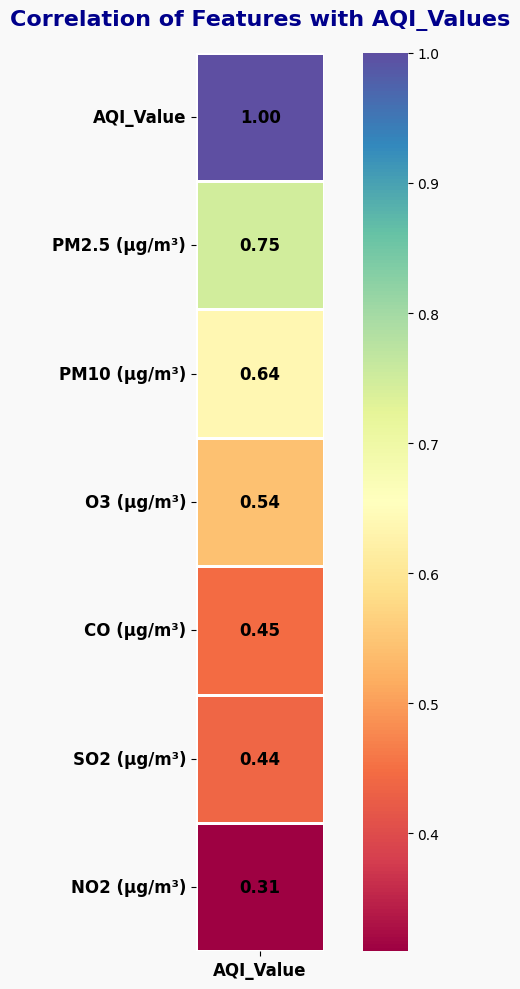

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Select only numeric columns relevant to pollution
numeric_cols = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
                'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)','AQI_Value']

# Correlation with dependent variable (CCME_Values)
corr = df_aqi[numeric_cols].corr()['AQI_Value'].sort_values(ascending=False)

# Plot heatmap
plt.figure(figsize=(8, 10), facecolor="#f9f9f9")

sns.heatmap(
    corr.to_frame(),
    annot=True,
    cmap="Spectral",
    cbar=True,
    fmt=".2f",
    annot_kws={"size": 12, "weight": "bold", "color": "black"},
    linewidths=0.8,
    linecolor="white",
    square=True
)

# Titles and labels styling
plt.title(
    "Correlation of Features with AQI_Values",
    fontsize=16,
    fontweight="bold",
    color="darkblue",
    pad=20
)

plt.xticks(fontsize=12, weight="bold", color="black")
plt.yticks(fontsize=12, weight="bold", color="black", rotation=0)

plt.tight_layout()
plt.show()

/tmp/ipykernel_691/772089555.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = df_aqi.groupby('AQI_Category', observed=True).apply(


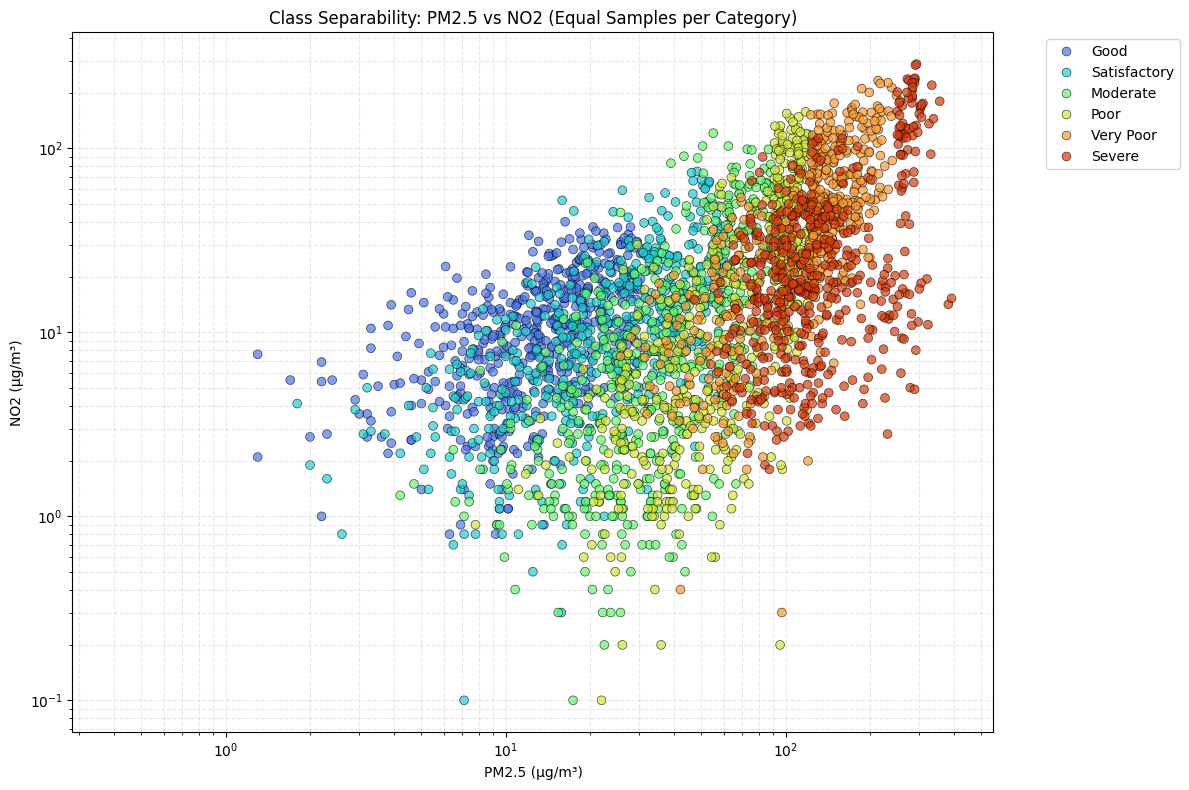

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# STRATIFIED SAMPLING FOR CLEAR VISUALIZATION
# ---------------------------------------------------------

# 1. Take 500 random samples from EACH category
# (If a category has less than 500, it takes all of them)
stratified_sample = df_aqi.groupby('AQI_Category', observed=True).apply(
    lambda x: x.sample(n=min(len(x), 500), random_state=42)
).reset_index(drop=True)

# 2. Plot the balanced data
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=stratified_sample,
    x='PM2.5 (µg/m³)',
    y='NO2 (µg/m³)',
    hue='AQI_Category',
    palette='turbo',  # 'turbo' gives very distinct high-contrast colors
    alpha=0.7,
    edgecolor='k',    # Adds a black border to dots for clarity
    s=40              # Slightly larger dots
)

plt.title('Class Separability: PM2.5 vs NO2 (Equal Samples per Category)')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside
plt.tight_layout()
plt.show()

/tmp/ipykernel_691/2347820974.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


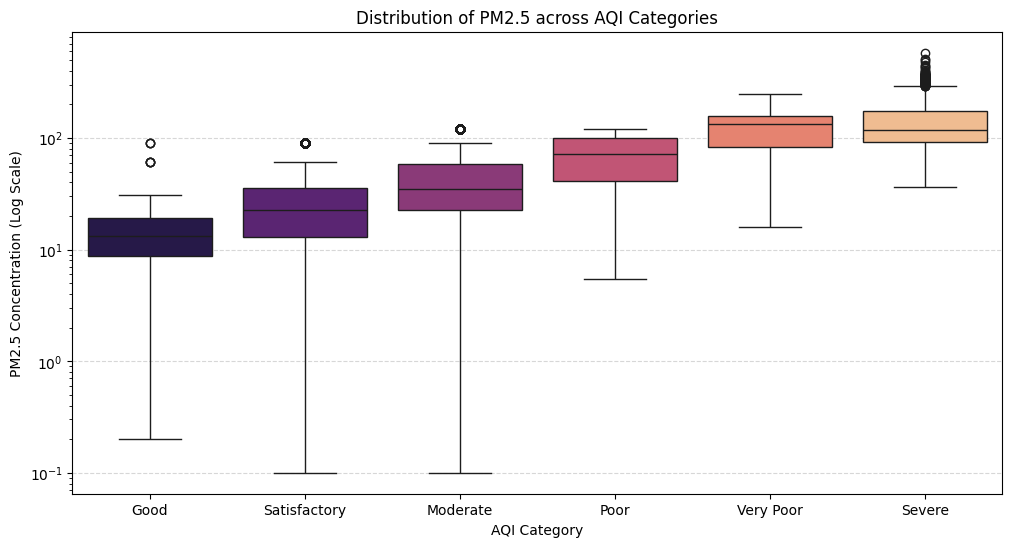

In [ ]:
plt.figure(figsize=(12, 6))

# We use PM2.5 as it's the main driver
sns.boxplot(
    data=df_aqi[df_aqi['AQI_Value'] > 0], # Filter bugs if any
    x='AQI_Category',
    y='PM2.5 (µg/m³)',
    palette='magma'
)

plt.title('Distribution of PM2.5 across AQI Categories')
plt.xlabel('AQI Category')
plt.ylabel('PM2.5 Concentration (Log Scale)')
plt.yscale('log') # Crucial for pollution data
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

BUILDING THE ENSEMBLE MODEL

In [ ]:
# SPLITTING AND DEFINING X & y

df_aqi = df_aqi.sort_values(by=['timestamp']).reset_index(drop=True)

features = [
    # Geography
    'Latitude', 'Longitude',
    # Pollutants
    'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
    'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)'
]


print(f"Total Features Selected: {len(features)}")

# Define Target
target = 'AQI_Value'

#  Calculate Split (85% Train, 15% Test)
split_index = int(len(df_aqi) * 0.85)

# Create Train/Test Sets
X_train = df_aqi.iloc[:split_index][features]
y_train = df_aqi.iloc[:split_index][target]

X_test = df_aqi.iloc[split_index:][features]
y_test = df_aqi.iloc[split_index:][target]

print(f"Training Data (Past):   {X_train.shape}")
print(f"Testing Data (Future):  {X_test.shape}")

Total Features Selected: 8
Training Data (Past):   (715761, 8)
Testing Data (Future):  (126311, 8)


In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

# TRAIN MODEL 2 - XGBOOST

print("1. Initializing XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=10,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

print("2. Training XGBoost (This might take slightly longer)...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

print("3. Predicting with XGBoost...")
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print("\n--- XGBoost Performance ---")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE:  {mae_xgb:.2f}")

1. Initializing XGBoost...
2. Training XGBoost (This might take slightly longer)...
[0]	validation_0-rmse:67.27747
[100]	validation_0-rmse:5.99854
[200]	validation_0-rmse:6.08206
[300]	validation_0-rmse:6.10067
[400]	validation_0-rmse:6.15051
[500]	validation_0-rmse:6.17947
[600]	validation_0-rmse:6.18812
[700]	validation_0-rmse:6.20734
[800]	validation_0-rmse:6.22087
[900]	validation_0-rmse:6.22870
[999]	validation_0-rmse:6.23556
3. Predicting with XGBoost...

--- XGBoost Performance ---
RMSE: 6.24
MAE:  1.04
